# Selective Prediction under Distribution Shift: Phase 1

**Kaggle setup before running:** Settings panel, Accelerator = GPU P100, Internet = On.

This notebook:
1. Downloads CIFAR-10 and CIFAR-10-C (direct Zenodo URL, no manual upload)
2. Trains N ResNet18 seeds on CIFAR-10 with a held out validation split
3. Dumps logits for val, clean test, and all 15 corruptions x 5 severities
4. Plots accuracy and mean confidence versus severity

Everything after step 3 is CPU work on a ~20 MB npz. Save Version when done so
`/kaggle/working/logits.npz` and `ckpt_*.pt` persist as a reusable notebook output.

In [1]:
import os, tarfile, urllib.request, time
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision as tv, torchvision.transforms as T

SEEDS      = [0, 1, 2]      # use 5 for the final run
EPOCHS     = 60
BATCH      = 128
VAL_N      = 5000           # held out from train, used for temp scaling + thresholds
WORK       = "/kaggle/working"
CDIR       = f"{WORK}/CIFAR-10-C"
DEV        = "cuda" if torch.cuda.is_available() else "cpu"
MEAN, STD  = (0.4914,0.4822,0.4465), (0.2470,0.2435,0.2616)

CORRUPTIONS = ["gaussian_noise","shot_noise","impulse_noise","defocus_blur","glass_blur",
               "motion_blur","zoom_blur","snow","frost","fog","brightness","contrast",
               "elastic_transform","pixelate","jpeg_compression"]
print(DEV, torch.cuda.get_device_name(0) if DEV=="cuda" else "")

cuda Tesla T4


## 1. Data

In [2]:
# CIFAR-10-C from Zenodo (~2.9 GB, ~5 min). Skipped if already present.
if not os.path.isdir(CDIR):
    url = "https://zenodo.org/record/2535967/files/CIFAR-10-C.tar"
    tar = f"{WORK}/cifar10c.tar"
    t0 = time.time(); urllib.request.urlretrieve(url, tar)
    print(f"downloaded in {time.time()-t0:.0f}s"); tarfile.open(tar).extractall(WORK); os.remove(tar)
print(sorted(os.listdir(CDIR))[:5], "...")

downloaded in 898s


/tmp/ipykernel_23/4292386819.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  print(f"downloaded in {time.time()-t0:.0f}s"); tarfile.open(tar).extractall(WORK); os.remove(tar)


['brightness.npy', 'contrast.npy', 'defocus_blur.npy', 'elastic_transform.npy', 'fog.npy'] ...


In [3]:
tf_train = T.Compose([T.RandomCrop(32,padding=4), T.RandomHorizontalFlip(),
                      T.ToTensor(), T.Normalize(MEAN,STD)])
tf_eval  = T.Compose([T.ToTensor(), T.Normalize(MEAN,STD)])

full  = tv.datasets.CIFAR10(f"{WORK}/data", train=True,  download=True, transform=tf_train)
fullv = tv.datasets.CIFAR10(f"{WORK}/data", train=True,  download=True, transform=tf_eval)
test  = tv.datasets.CIFAR10(f"{WORK}/data", train=False, download=True, transform=tf_eval)

rng = np.random.default_rng(12345)                 # FIXED split, shared by all seeds
perm = rng.permutation(len(full)); val_idx, tr_idx = perm[:VAL_N], perm[VAL_N:]
tr_ds, val_ds = Subset(full, tr_idx), Subset(fullv, val_idx)

dl = lambda d,s: DataLoader(d, batch_size=BATCH if s else 512, shuffle=s,
                            num_workers=2, pin_memory=True, drop_last=s)
tr_dl, val_dl, test_dl = dl(tr_ds,True), dl(val_ds,False), dl(test,False)
print(len(tr_ds), len(val_ds), len(test))

100%|██████████| 170M/170M [18:43<00:00, 152kB/s]


45000 5000 10000


## 2. Model

torchvision ResNet18 with the CIFAR stem: 3x3 conv, no maxpool. The ImageNet stem
throws away too much on 32x32 inputs and costs ~4 points of accuracy.

In [4]:
def resnet18_cifar():
    m = tv.models.resnet18(weights=None, num_classes=10)
    m.conv1 = nn.Conv2d(3, 64, 3, 1, 1, bias=False)
    m.maxpool = nn.Identity()
    return m

## 3. Train

In [5]:
def train_one(seed):
    torch.manual_seed(seed); np.random.seed(seed)
    m = resnet18_cifar().to(DEV).to(memory_format=torch.channels_last)
    opt = torch.optim.SGD(m.parameters(), lr=0.1, momentum=0.9,
                          weight_decay=5e-4, nesterov=True)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, 0.1, epochs=EPOCHS,
                                                steps_per_epoch=len(tr_dl))
    scaler = torch.cuda.amp.GradScaler()
    for ep in range(EPOCHS):
        m.train()
        for x,y in tr_dl:
            x = x.to(DEV,non_blocking=True).to(memory_format=torch.channels_last)
            y = y.to(DEV,non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast():
                loss = F.cross_entropy(m(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
        if (ep+1) % 20 == 0:
            print(f"  seed {seed} ep {ep+1}/{EPOCHS} loss {loss.item():.3f}", flush=True)
    return m

models = {}
for s in SEEDS:
    p = f"{WORK}/ckpt_{s}.pt"
    m = resnet18_cifar().to(DEV)
    if os.path.exists(p):
        m.load_state_dict(torch.load(p)); print(f"seed {s}: loaded")
    else:
        t0 = time.time(); m = train_one(s); torch.save(m.state_dict(), p)
        print(f"seed {s}: trained in {(time.time()-t0)/60:.1f} min")
    models[s] = m.eval()

/tmp/ipykernel_23/127386162.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_23/127386162.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  seed 0 ep 20/60 loss 0.328
  seed 0 ep 40/60 loss 0.161
  seed 0 ep 60/60 loss 0.011
seed 0: trained in 13.1 min
  seed 1 ep 20/60 loss 0.401
  seed 1 ep 40/60 loss 0.240
  seed 1 ep 60/60 loss 0.011
seed 1: trained in 13.3 min
  seed 2 ep 20/60 loss 0.408
  seed 2 ep 40/60 loss 0.148
  seed 2 ep 60/60 loss 0.002
seed 2: trained in 13.3 min


## 4. Logit dump

One forward pass over everything, stored as float16. Every downstream analysis
(calibration, thresholds, risk coverage curves, per class abstention) reads this
file and needs no GPU.

In [6]:
@torch.no_grad()
def logits_from_array(m, x_uint8):
    """x_uint8: (N,32,32,3) uint8 -> (N,10) float16 logits"""
    out, mean, std = [], torch.tensor(MEAN).view(1,3,1,1), torch.tensor(STD).view(1,3,1,1)
    for i in range(0, len(x_uint8), 1000):
        b = torch.from_numpy(x_uint8[i:i+1000]).permute(0,3,1,2).float().div_(255)
        b = ((b-mean)/std).to(DEV)
        with torch.cuda.amp.autocast():
            out.append(m(b).float().cpu())
    return torch.cat(out).half().numpy()

@torch.no_grad()
def logits_from_loader(m, loader):
    out = [m(x.to(DEV)).float().cpu() for x,_ in loader]
    return torch.cat(out).half().numpy()

In [7]:
# CRITICAL: each corruption .npy is (50000,32,32,3) = the SAME 10000 test images
# at 5 severities, stacked in order. Slice [(s-1)*10000 : s*10000] or your
# accuracy-vs-severity curve silently flattens into the 5-severity average.
c_labels = np.load(f"{CDIR}/labels.npy")
assert (c_labels[:10000] == c_labels[10000:20000]).all()

store = {"y_val":   np.array([fullv[i][1] for i in val_idx]),
         "y_test":  np.array(test.targets),
         "y_corr":  c_labels[:10000]}

for s, m in models.items():
    store[f"val_{s}"]  = logits_from_loader(m, val_dl)
    store[f"test_{s}"] = logits_from_loader(m, test_dl)

for c in CORRUPTIONS:
    raw = np.load(f"{CDIR}/{c}.npy")
    for sev in range(1, 6):
        x = raw[(sev-1)*10000 : sev*10000]
        for s, m in models.items():
            store[f"{c}_{sev}_{s}"] = logits_from_array(m, x)
    print(c, flush=True)

np.savez_compressed(f"{WORK}/logits.npz", **store)
print(f"{os.path.getsize(WORK+'/logits.npz')/1e6:.1f} MB")

/tmp/ipykernel_23/2220388516.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


gaussian_noise
shot_noise
impulse_noise
defocus_blur
glass_blur
motion_blur
zoom_blur
snow
frost
fog
brightness
contrast
elastic_transform
pixelate
jpeg_compression
41.6 MB


## 5. Sanity check

If accuracy falls far faster than mean confidence, you have reproduced the core
effect the whole project is built on.

sev 0  acc  94.4%  conf  97.4%  gap  +3.0
sev 1  acc  86.6%  conf  94.7%  gap  +8.1
sev 2  acc  80.7%  conf  92.8%  gap +12.1
sev 3  acc  74.5%  conf  91.0%  gap +16.5
sev 4  acc  67.0%  conf  88.6%  gap +21.6
sev 5  acc  55.4%  conf  85.1%  gap +29.7


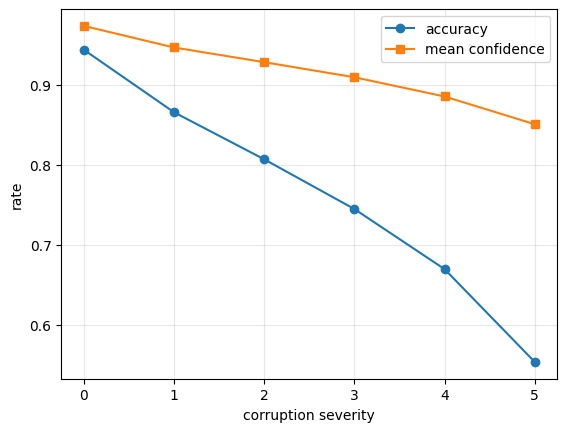

In [8]:
import matplotlib.pyplot as plt
d = np.load(f"{WORK}/logits.npz")

def acc_conf(lg, y):
    p = torch.softmax(torch.from_numpy(lg).float(), 1)
    conf, pred = p.max(1)
    return (pred.numpy()==y).mean(), conf.mean().item()

s0, y = SEEDS[0], d["y_corr"]
rows = [(0,)+acc_conf(d[f"test_{s0}"], d["y_test"])]
for sev in range(1,6):
    a, c = zip(*[acc_conf(d[f"{k}_{sev}_{s0}"], y) for k in CORRUPTIONS])
    rows.append((sev, np.mean(a), np.mean(c)))

sev, acc, conf = zip(*rows)
for r in rows: print(f"sev {r[0]}  acc {r[1]*100:5.1f}%  conf {r[2]*100:5.1f}%  gap {(r[2]-r[1])*100:+5.1f}")
plt.plot(sev, acc, "o-", label="accuracy"); plt.plot(sev, conf, "s-", label="mean confidence")
plt.xlabel("corruption severity"); plt.ylabel("rate"); plt.legend(); plt.grid(alpha=.3); plt.show()

## Next

`logits.npz` is now the only input you need. Phase 2 is pure numpy: temperature
scaling fit on `val_*`, ECE and Brier per severity, then the actual contribution,
picking an abstention threshold on clean val for a target risk and measuring how
badly the realised risk misses it on every corruption and severity.